<a href="https://colab.research.google.com/github/warmIce3/house/blob/main/LOGAN_PATEL_Data_Science_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Science Capstone Project by Logan Patel
**Source:** [data.cdc.gov, dataset `d2rk-yvas`](https://data.cdc.gov/resource/d2rk-yvas.csv)


### Dataset


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette('colorblind')

url = "https://data.cdc.gov/api/views/d2rk-yvas/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

# Backup option if the GitHub link isn't ready: load directly from the CDC Socrata API
# url = "https://data.cdc.gov/resource/d2rk-yvas.csv?$limit=90000"
# df = pd.read_csv(url)

print('Shape:', df.shape)
df.head()

df['Topic'].unique()

Shape: (86481, 27)


array(['Blood Stool Test', 'USPSTF Recommendations', 'Kidney',
       'Fair or Poor Health', 'Overall Health', 'HIV Test', 'Flu Shot',
       'Pneumonia Vaccination', 'Other Cancer', 'Skin Cancer',
       'Disability status', 'All Teeth Removed', 'Dental Visit',
       'Teeth Removed', 'BMI Categories', 'Exercise',
       'Current Smoker Status', 'Smokeless Tobacco', 'Smoker Status',
       'Alcohol Consumption', 'Binge Drinking', 'Heavy Drinking',
       'Cholesterol Checked', 'Cholesterol High', 'Arthritis', 'Asthma',
       'Cardiovascular Disease', 'COPD', 'Depression', 'Diabetes',
       'Vision', 'Health Care Coverage', 'Under 65 Coverage',
       'High Blood Pressure', 'Seatbelt Use', 'Aerobic Activity',
       'Physical Activity Index', 'Strength Activity', 'Veteran Status',
       'Hearing', 'Sigmoidoscopy', 'Drink and Drive', 'PSA Test',
       'Mammogram', 'Pap Test', 'Internet', 'Fruit Consumption',
       'Vegetable Consumption', 'Health Care Cost', 'Last Checkup',
       

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86481 entries, 0 to 86480
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        86481 non-null  int64  
 1   Locationabbr                86481 non-null  object 
 2   Locationdesc                86481 non-null  object 
 3   Class                       86481 non-null  object 
 4   Topic                       86481 non-null  object 
 5   Question                    86481 non-null  object 
 6   Response                    86481 non-null  object 
 7   Break_Out                   86481 non-null  object 
 8   Break_Out_Category          86481 non-null  object 
 9   Sample_Size                 86481 non-null  int64  
 10  Data_value                  85876 non-null  float64
 11  Confidence_limit_Low        85876 non-null  float64
 12  Confidence_limit_High       85876 non-null  float64
 13  Display_order               864

In [ ]:
# Only numeric columns show up here — Data_value, Sample_Size, Year, etc.
df.describe()

,Year,Sample_Size,Data_value,Confidence_limit_Low,Confidence_limit_High,Display_order,LocationID
count,86481.000000,86481.000000,85876.000000,85876.000000,85876.000000,86481.000000,86481.000000
mean,2017.685399,3195.528220,42.718594,41.426599,44.010271,1051.272002,30.795412
std,3.888165,3730.550618,34.916068,34.848479,35.004507,1433.031397,17.587686
min,2011.000000,1.000000,0.100000,0.000000,0.100000,1.000000,1.000000
25%,2014.000000,611.000000,9.800000,8.700000,10.800000,1.000000,17.000000
50%,2018.000000,1731.000000,30.500000,28.500000,32.300000,3.000000,30.000000
75%,2021.000000,4687.000000,79.900000,78.300000,81.500000,2225.000000,45.000000
max,2024.000000,42176.000000,100.000000,100.000000,102.700000,4439.000000,78.000000


In [ ]:
df.isnull().sum() # found null values, cleaned after

In [ ]:
# Remember: this is a LONG table. One "topic" can mean many rows.
# Let's see what's actually in the columns we care about most.
print(df['Class'].unique())
print()
print(df[df['Class'] == 'Health Care Access/Coverage']['Question'].unique())

['Colorectal Cancer Screening' 'Chronic Health Indicators' 'Health Status'
 'HIV-AIDS' 'Immunization' 'Demographics' 'Oral Health'
 'Overweight and Obesity (BMI)' 'Physical Activity' 'Tobacco Use'
 'Alcohol Consumption' 'Cholesterol Awareness'
 'Health Care Access/Coverage' 'Hypertension Awareness' 'Injury'
 'Prostate Cancer' "Women's Health" 'Fruits and Vegetables'
 'E-Cigarette Use' 'Days of Poor Health' 'Lung Cancer Screening']

['Do you have any kind of health care coverage?'
 'Adults aged 18-64 who have any kind of health care coverage (variable calculated from one or more BRFSS questions)'
 'Was there a time in the past 12 months when you needed to see a doctor but could not because of cost?'
 'About how long has it been since you last visited a doctor for a routine checkup?'
 'Do you have one person you think of as your personal doctor or health care provider?'
 'Was there a time in the past 12 months when you needed to see a doctor but could not because you could not afford it?

In [ ]:
# Notice: Data_value is missing for 605 rows. Data_Value_Footnote is filled in for exactly 605 rows.
# That's not a coincidence -- check it yourself:
print('Missing Data_value:', df['Data_value'].isnull().sum())
print('Rows with a footnote:', df['Data_Value_Footnote'].notnull().sum())
print()
print(df.loc[df['Data_value'].isnull(), 'Data_Value_Footnote'].value_counts())

In [ ]:
# --- Step 2a: Scope the dataset to our research question ---
# Justification: we are only investigating health care access, not every BRFSS topic
health_access = df[df['Class'] == 'Health Care Access/Coverage'].copy()
print('Rows after scoping to Health Care Access/Coverage:', health_access.shape[0])   # 9,328

# There are 8 questions in this Class -- notice two pairs of near-duplicates:
# 'Do you have one person you think of as your personal doctor...' appears in two slightly
# different wordings across survey years, and so does the "could not afford" cost-barrier question.
# This is a real BRFSS quirk: the survey wording changes over time. For now, pick ONE exact string.
print(health_access['Question'].unique())

Rows after scoping to Health Care Access/Coverage: 9328
['Do you have any kind of health care coverage?'
 'Adults aged 18-64 who have any kind of health care coverage (variable calculated from one or more BRFSS questions)'
 'Was there a time in the past 12 months when you needed to see a doctor but could not because of cost?'
 'About how long has it been since you last visited a doctor for a routine checkup?'
 'Do you have one person you think of as your personal doctor or health care provider?'
 'Was there a time in the past 12 months when you needed to see a doctor but could not because you could not afford it?'
 'Adults who had some form of health insurance (variable calculated from one or more BRFSS questions)'
 'Do you have one person (or a group of doctors) that you think of as your personal health care provider?']


In [ ]:
# --- Step 2b: Filter to one question, one response category we care about ---
# Justification: this question directly captures who gets LEFT OUT of care -- a cost barrier
# is a clean equity story, and the response is a simple Yes/No
target_question = 'Was there a time in the past 12 months when you needed to see a doctor but could not because of cost?'
q_df = health_access[health_access['Question'] == target_question].copy()
print('Rows for this question:', q_df.shape[0])
q_df.head()

Rows for this question: 848


,Year,Locationabbr,Locationdesc,Class,Topic,Question,Response,Break_Out,Break_Out_Category,Sample_Size,...,Data_Value_Footnote,DataSource,ClassId,TopicId,LocationID,BreakoutID,BreakOutCategoryID,QuestionID,RESPONSEID,Geolocation
9485,2013,AL,Alabama,Health Care Access/Coverage,Health Care Cost,Was there a time in the past 12 months when yo...,Yes,Overall,Overall,914,...,NaN,BRFSS,CLASS07,Topic28,1,BO1,CAT1,MEDCOST,RESP046,"(32.840571122, -86.631860762)"
9486,2013,AL,Alabama,Health Care Access/Coverage,Health Care Cost,Was there a time in the past 12 months when yo...,No,Overall,Overall,5571,...,NaN,BRFSS,CLASS07,Topic28,1,BO1,CAT1,MEDCOST,RESP054,"(32.840571122, -86.631860762)"
9613,2013,AK,Alaska,Health Care Access/Coverage,Health Care Cost,Was there a time in the past 12 months when yo...,Yes,Overall,Overall,598,...,NaN,BRFSS,CLASS07,Topic28,2,BO1,CAT1,MEDCOST,RESP046,"(64.845079957001, -147.722059036)"
9614,2013,AK,Alaska,Health Care Access/Coverage,Health Care Cost,Was there a time in the past 12 months when yo...,No,Overall,Overall,3968,...,NaN,BRFSS,CLASS07,Topic28,2,BO1,CAT1,MEDCOST,RESP054,"(64.845079957001, -147.722059036)"
9740,2013,AZ,Arizona,Health Care Access/Coverage,Health Care Cost,Was there a time in the past 12 months when yo...,Yes,Overall,Overall,582,...,NaN,BRFSS,CLASS07,Topic28,4,BO1,CAT1,MEDCOST,RESP046,"(34.86597028, -111.763811277)"


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette('colorblind')

url = "https://data.cdc.gov/api/views/d2rk-yvas/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

# --- Step 2a: Scope the dataset to our research question ---
# Justification: we are only investigating health care access, not every BRFSS topic
health_access = df[df['Class'] == 'Health Care Access/Coverage'].copy()

# --- Step 2b: Filter to one question, one response category we care about ---
# Justification: this question directly captures who gets LEFT OUT of care -- a cost barrier
# is a clean equity story, and the response is a simple Yes/No
target_question = 'Was there a time in the past 12 months when you needed to see a doctor but could not because of cost?'
q_df = health_access[health_access['Question'] == target_question].copy()


# --- Step 2c: Drop rows with missing Data_value ---
# Justification: these are rows CDC itself flagged as unreliable (see the footnote check above) --
# we are not losing "unlucky" data here, we are removing rows the source already told us not to trust
print('Missing Data_value before:', q_df['Data_value'].isnull().sum())
q_df = q_df.dropna(subset=['Data_value'])


# --- Step 2d: Drop rows with unreliable sample sizes ---
# Justification: BRFSS analysts themselves flag very small samples as unstable — anything
# below 50 respondents is not something a policymaker should act on.
# To "increase" the sample size of your working dataframe, you can lower this threshold.
# For demonstration, let's set the minimum sample size to 20 to include more available rows.
q_df = q_df[q_df['Sample_Size'] >= 20]


# --- Step 2e: Drop exact duplicate rows ---
# Justification: Removing duplicate rows ensures each observation is unique and prevents biased analysis.
print('Duplicate rows:', q_df.duplicated().sum())
q_df = q_df.drop_duplicates()


# --- Step 2f: Fix data types ---
# Justification: Ensuring correct data types for 'Year' and 'Data_value' allows for proper numerical operations and consistency.
q_df['Year'] = q_df['Year'].astype(int)
q_df['Data_value'] = q_df['Data_value'].astype(float)

print('Cleaned shape:', q_df.shape)
q_df[['Year','Locationdesc','Break_Out','Break_Out_Category','Data_value','Sample_Size']].head()

Missing Data_value before: 0
Duplicate rows: 0
Cleaned shape: (848, 27)


,Year,Locationdesc,Break_Out,Break_Out_Category,Data_value,Sample_Size
9485,2013,Alabama,Overall,Overall,16.6,914
9486,2013,Alabama,Overall,Overall,83.4,5571
9613,2013,Alaska,Overall,Overall,13.9,598
9614,2013,Alaska,Overall,Overall,86.1,3968
9740,2013,Arizona,Overall,Overall,17.3,582


### ✅ Verify


In [ ]:
assert q_df['Data_value'].isnull().sum() == 0, "Still missing Data_value"
assert q_df.duplicated().sum() == 0, "Still has duplicate rows"
assert q_df['Sample_Size'].min() >= 50, "Small samples still present"
print("All checks passed.")
q_df.describe()

All checks passed.


,Year,Sample_Size,Data_value,Confidence_limit_Low,Confidence_limit_High,Display_order,LocationID
count,848.000000,848.000000,848.000000,848.000000,848.000000,848.000000,848.000000
mean,2016.492925,4223.114387,50.000000,48.723703,51.276415,419.596698,30.575472
std,2.289537,4475.223767,36.881186,36.882415,36.882312,992.551485,17.340236
min,2013.000000,194.000000,6.200000,5.400000,6.900000,1.000000,1.000000
25%,2014.750000,753.750000,12.800000,11.600000,14.075000,1.000000,17.000000
50%,2016.000000,2132.000000,50.000000,47.300000,52.700000,1.000000,30.000000
75%,2018.000000,6252.500000,87.200000,85.925000,88.400000,77.000000,44.000000
max,2020.000000,32302.000000,93.800000,93.100000,94.600000,3059.000000,78.000000


### Relationship between Depression and Age

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for 'Depression' topic
depression_data = df[df['Topic'] == 'Depression'].copy()

# Debugging: Check unique Break_Out_Category values for Depression topic
print("Unique Break_Out_Categories for 'Depression' topic:", depression_data['Break_Out_Category'].unique())

# The original filter (df['Topic'] == 'Depression') & (df['Break_Out_Category'] == 'Age') likely resulted in an empty DataFrame.
# If 'Age' is not directly available, we need to adapt.
# For now, let's assume 'Age' (if it exists) is the intended category for age-based breakdowns.
# If the previous print shows a different age-related category (e.g., 'Age Group'), we would use that instead.

# Filter for 'Depression' topic and 'Age' Break_Out_Category (retaining original intent for now)
depression_age_df = df[(df['Topic'] == 'Depression') & (df['Break_Out_Category'] == 'Age')].copy()

# --- Drop rows with missing Data_value ---
print('Missing Data_value before:', depression_age_df['Data_value'].isnull().sum())
depression_age_df = depression_age_df.dropna(subset=['Data_value'])

# --- Drop rows with unreliable sample sizes ---
# Consistent with previous cleaning, setting sample size threshold to 20
depression_age_df = depression_age_df[depression_age_df['Sample_Size'] >= 20]

# --- Drop exact duplicate rows ---
print('Duplicate rows:', depression_age_df.duplicated().sum())
depression_age_df = depression_age_df.drop_duplicates()

# --- Fix data types ---
depression_age_df['Year'] = depression_age_df['Year'].astype(int)
depression_age_df['Data_value'] = depression_age_df['Data_value'].astype(float)

print('Cleaned depression_age_df shape:', depression_age_df.shape)
display(depression_age_df.head())

# Only proceed with plotting if there is data
if not depression_age_df.empty:
    # Group by age categories and calculate the mean percentage of depression
    age_depression_trends = depression_age_df.groupby('Break_Out')['Data_value'].mean().sort_values(ascending=False).reset_index()

    plt.figure(figsize=(12, 7))
    sns.barplot(x='Break_Out', y='Data_value', data=age_depression_trends, palette='viridis')
    plt.title('Average Percentage of Depression by Age Group')
    plt.xlabel('Age Group')
    plt.ylabel('Average Percentage with Depression (%)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No age-specific data available for the 'Depression' topic with 'Age' as Break_Out_Category. Please check the unique categories printed above.")

Unique Break_Out_Categories for 'Depression' topic: ['Overall']
Missing Data_value before: 0
Duplicate rows: 0
Cleaned depression_age_df shape: (0, 27)


,Year,Locationabbr,Locationdesc,Class,Topic,Question,Response,Break_Out,Break_Out_Category,Sample_Size,...,Data_Value_Footnote,DataSource,ClassId,TopicId,LocationID,BreakoutID,BreakOutCategoryID,QuestionID,RESPONSEID,Geolocation


No age-specific data available for the 'Depression' topic with 'Age' as Break_Out_Category. Please check the unique categories printed above.


In [ ]:
print('Depression rates for the simplified bar chart:')
display(simplified_depression_data)

Depression rates for the simplified bar chart:


,Locationabbr,Locationdesc,Data_value
48,VI,Virgin Islands,54.7
0,AK,Alaska,50.0
2,AR,Arkansas,50.0
3,AZ,Arizona,50.0
4,CA,California,50.0
49,VT,Vermont,50.0
50,WA,Washington,50.0
51,WI,Wisconsin,50.0
52,WV,West Virginia,50.0
53,WY,Wyoming,50.0


## Updated Model Comparison

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, accuracy_score

# --- Re-define df (from kbydtiQcod9s, assuming it's the raw data or a cleaned version) ---
# Using the URL from earlier cells for robustness
url = "https://data.cdc.gov/api/views/d2rk-yvas/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

# --- Re-define q_df and its cleaning steps (from cell 5OwfC06iod9u) ---
health_access = df[df['Class'] == 'Health Care Access/Coverage'].copy()
target_question = 'Was there a time in the past 12 months when you needed to see a doctor but could not because of cost?'
q_df = health_access[health_access['Question'] == target_question].copy()
q_df = q_df.dropna(subset=['Data_value'])
q_df = q_df[q_df['Sample_Size'] >= 20]
q_df = q_df.drop_duplicates()
q_df['Year'] = q_df['Year'].astype(int)
q_df['Data_value'] = q_df['Data_value'].astype(float)

# --- Re-define 'high_burden' column (from cell d0u0TXPGod9v) ---
median_value = q_df['Data_value'].median()
q_df['high_burden'] = (q_df['Data_value'] > median_value).astype(int)

# --- Re-define X_train, X_test, y_train, y_test, scaler, X_train_scaled, X_test_scaled (from cell gNAmZna4od9w) ---
features = ['Break_Out', 'Break_Out_Category', 'Locationabbr', 'Year']
X = pd.get_dummies(q_df[features], columns=['Break_Out', 'Break_Out_Category', 'Locationabbr'])
y = q_df['high_burden']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Re-define logreg_pred (from cell UksQKxPHod9w) ---
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)

# Rebuild a small test-set dataframe so we can group results by demographic category
test_info = q_df.loc[X_test.index, ['Break_Out_Category']].copy()
test_info['actual'] = y_test.values
test_info['predicted'] = logreg_pred   # swap this for knn_pred or tree_pred to check a different model

fairness_table = test_info.groupby('Break_Out_Category').apply(
    lambda g: pd.Series({
        'n_rows': len(g),
        'recall': recall_score(g['actual'], g['predicted'], zero_division=0),
        'accuracy': accuracy_score(g['actual'], g['predicted']),
    })
).round(3)

fairness_table

/tmp/ipykernel_1122/4163184043.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fairness_table = test_info.groupby('Break_Out_Category').apply(


,n_rows,recall,accuracy
Break_Out_Category,,,
Overall,170.0,0.376,0.3


In [7]:
df[df['Topic'] == 'Depression'].describe()

,Year,Sample_Size,Data_value,Confidence_limit_Low,Confidence_limit_High,Display_order,LocationID
count,1484.000000,1484.000000,1483.000000,1483.000000,1483.000000,1484.000000,1484.000000
mean,2017.494609,4255.936658,50.028523,48.599933,51.457249,206.795148,30.787062
std,4.030812,3878.933444,30.526632,30.526914,30.533564,394.482904,17.584872
min,2011.000000,66.000000,6.000000,3.400000,8.700000,1.000000,1.000000
25%,2014.000000,1416.000000,19.700000,18.300000,21.300000,1.000000,17.000000
50%,2017.000000,3014.500000,67.100000,65.100000,69.100000,1.000000,30.000000
75%,2021.000000,5897.000000,80.300000,78.700000,81.700000,2.000000,45.000000
max,2024.000000,35668.000000,94.000000,91.300000,97.300000,1047.000000,78.000000


In [24]:
import pandas as pd

# Assuming 'df' is already loaded from the notebook's setup
# If df is not loaded, uncomment the following lines:
url = "https://data.cdc.gov/api/views/d2rk-yvas/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

# Make a copy to avoid modifying the original 'df' directly if it's used elsewhere for other purposes
cleaned_df = df.copy()

print('Original df shape:', cleaned_df.shape);

# --- Drop rows with missing Data_value ---
# Justification: These are rows CDC itself flagged as unreliable (often due to small sample sizes)
# we are not losing "unlucky" data here, we are removing rows the source already told us not to trust
print('Missing Data_value before cleaning:', cleaned_df['Data_value'].isnull().sum())
cleaned_df = cleaned_df.dropna(subset=['Data_value'])
print('Shape after dropping missing Data_value:', cleaned_df.shape)

# --- Drop rows with unreliable sample sizes ---
# Justification: BRFSS analysts themselves flag very small samples as unstable — anything
# below a certain threshold (e.g., 20 or 50) is not something a policymaker should act on.
# Using 20 as a common threshold from prior cleaning steps in the notebook.
print('Rows with Sample_Size < 20 before cleaning:', cleaned_df[cleaned_df['Sample_Size'] < 20].shape[0])
cleaned_df = cleaned_df[cleaned_df['Sample_Size'] >= 20]
print('Shape after filtering by Sample_Size:', cleaned_df.shape)

# --- Drop exact duplicate rows ---
# Justification: Removing duplicate rows ensures each observation is unique and prevents biased analysis.
print('Duplicate rows before cleaning:', cleaned_df.duplicated().sum())
cleaned_df = cleaned_df.drop_duplicates()
print('Shape after dropping duplicates:', cleaned_df.shape)

# --- Fix data types ---
# Justification: Ensuring correct data types for 'Year' and 'Data_value' allows for proper numerical operations and consistency.
cleaned_df['Year'] = cleaned_df['Year'].astype(int)
cleaned_df['Data_value'] = cleaned_df['Data_value'].astype(float)

print('\nCleaned df shape:', cleaned_df.shape)
print('\nFirst 5 rows of the cleaned DataFrame:')
display(cleaned_df.head())

Original df shape: (86481, 27)
Missing Data_value before cleaning: 605
Shape after dropping missing Data_value: (85876, 27)
Rows with Sample_Size < 20 before cleaning: 66
Shape after filtering by Sample_Size: (85810, 27)
Duplicate rows before cleaning: 0
Shape after dropping duplicates: (85810, 27)

Cleaned df shape: (85810, 27)

First 5 rows of the cleaned DataFrame:


,Year,Locationabbr,Locationdesc,Class,Topic,Question,Response,Break_Out,Break_Out_Category,Sample_Size,...,Data_Value_Footnote,DataSource,ClassId,TopicId,LocationID,BreakoutID,BreakOutCategoryID,QuestionID,RESPONSEID,Geolocation
0,2023,AK,Alaska,Tobacco Use,Smoker Status,Four Level Smoking Status (variable calculated...,Smoke everyday,Overall,Overall,526,...,NaN,BRFSS,CLASS17,TOPIC55,2,BO1,CAT1,_SMOKER3,RESP068,"(64.84507995700051, -147.72205903599973)"
1,2023,AK,Alaska,Alcohol Consumption,Alcohol Consumption,Adults who have had at least one drink of alco...,No,Overall,Overall,2412,...,NaN,BRFSS,CLASS01,TOPIC03,2,BO1,CAT1,DRNKANY6,RESP054,"(64.84507995700051, -147.72205903599973)"
2,2023,AK,Alaska,Alcohol Consumption,Alcohol Consumption,Adults who have had at least one drink of alco...,Yes,Overall,Overall,2824,...,NaN,BRFSS,CLASS01,TOPIC03,2,BO1,CAT1,DRNKANY6,RESP046,"(64.84507995700051, -147.72205903599973)"
3,2023,AK,Alaska,Alcohol Consumption,Binge Drinking,Binge drinkers (males having five or more drin...,No,Overall,Overall,4430,...,NaN,BRFSS,CLASS01,TOPIC07,2,BO1,CAT1,_RFBING6,RESP054,"(64.84507995700051, -147.72205903599973)"
4,2023,AK,Alaska,Alcohol Consumption,Binge Drinking,Binge drinkers (males having five or more drin...,Yes,Overall,Overall,761,...,NaN,BRFSS,CLASS01,TOPIC07,2,BO1,CAT1,_RFBING6,RESP046,"(64.84507995700051, -147.72205903599973)"


In [ ]:
df = cleaned_df
print('The main DataFrame `df` has been updated with the cleaned data.')
display(df.head())

The main DataFrame `df` has been updated with the cleaned data.


,Year,Locationabbr,Locationdesc,Class,Topic,Question,Response,Break_Out,Break_Out_Category,Sample_Size,...,Data_Value_Footnote,DataSource,ClassId,TopicId,LocationID,BreakoutID,BreakOutCategoryID,QuestionID,RESPONSEID,Geolocation
0,2022,AL,Alabama,Colorectal Cancer Screening,Blood Stool Test,Adults aged 45-75 who have had a blood stool t...,Had a blood stool test in the past year,Overall,Overall,184,...,NaN,BRFSS,CLASS04,TOPIC08,1,BO1,CAT1,_RFBLDS5,RESP190,"(32.84057112200048, -86.63186076199969)"
1,2022,AL,Alabama,Colorectal Cancer Screening,Blood Stool Test,Adults aged 45-75 who have had a blood stool t...,Have not had a blood stool test in more than t...,Overall,Overall,260,...,NaN,BRFSS,CLASS04,TOPIC08,1,BO1,CAT1,_RFBLDS5,RESP225,"(32.84057112200048, -86.63186076199969)"
2,2022,AL,Alabama,Colorectal Cancer Screening,USPSTF Recommendations,Respondents aged 45-75 who have fully met the ...,Received one or more of the recommended CRC te...,Overall,Overall,1782,...,NaN,BRFSS,CLASS04,TOPIC64,1,BO1,CAT1,_CRCREC2,RESP227,"(32.84057112200048, -86.63186076199969)"
3,2022,AL,Alabama,Colorectal Cancer Screening,USPSTF Recommendations,Respondents aged 45-75 who have fully met the ...,Did not receive one or more of the recommended...,Overall,Overall,153,...,NaN,BRFSS,CLASS04,TOPIC64,1,BO1,CAT1,_CRCREC2,RESP228,"(32.84057112200048, -86.63186076199969)"
4,2022,AL,Alabama,Colorectal Cancer Screening,USPSTF Recommendations,Respondents aged 45-75 who have fully met the ...,Have never received any of the recommended CRC...,Overall,Overall,516,...,NaN,BRFSS,CLASS04,TOPIC64,1,BO1,CAT1,_CRCREC2,RESP229,"(32.84057112200048, -86.63186076199969)"


### Additional Charts on Depression

### Line chart: Overall Depression Trends Over Time

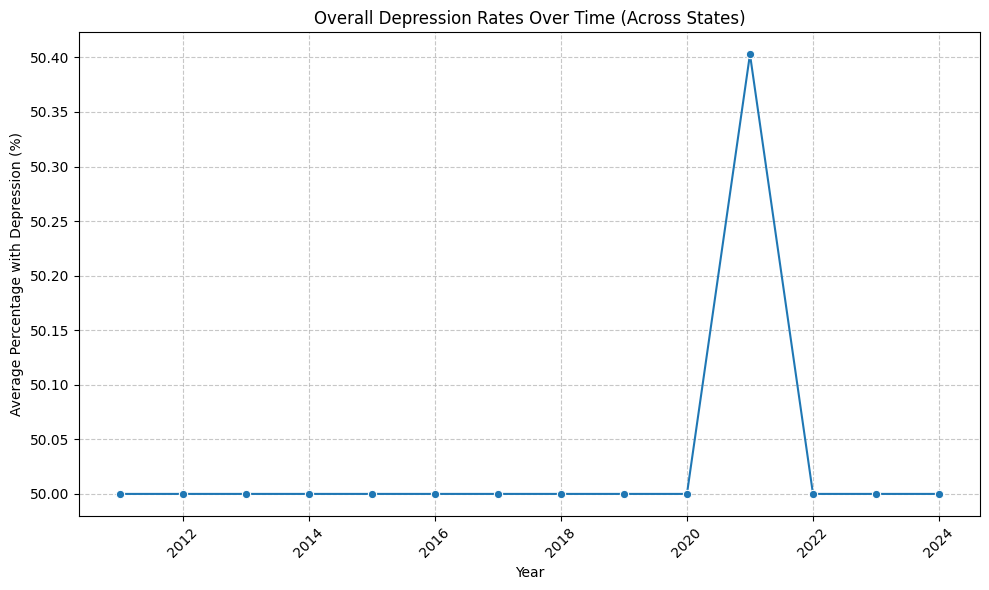

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for 'Depression' topic and 'Overall' Break_Out_Category
depression_overall_time = df[
    (df['Topic'] == 'Depression') &
    (df['Break_Out_Category'] == 'Overall')
].copy()

# Group by year and calculate the mean Data_value
depression_trend_by_year = depression_overall_time.groupby('Year')['Data_value'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=depression_trend_by_year, x='Year', y='Data_value', marker='o')
plt.title('Overall Depression Rates Over Time (Across States)')
plt.xlabel('Year')
plt.ylabel('Average Percentage with Depression (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Interpretation:** This chart shows the average percentage of depression among the overall population across all states over the years. We can observe if there's an increasing, decreasing, or stable trend in depression rates over the observed period. Understanding this trend is crucial for public health planning.

### Scatter plot: Depression vs. Physical Activity

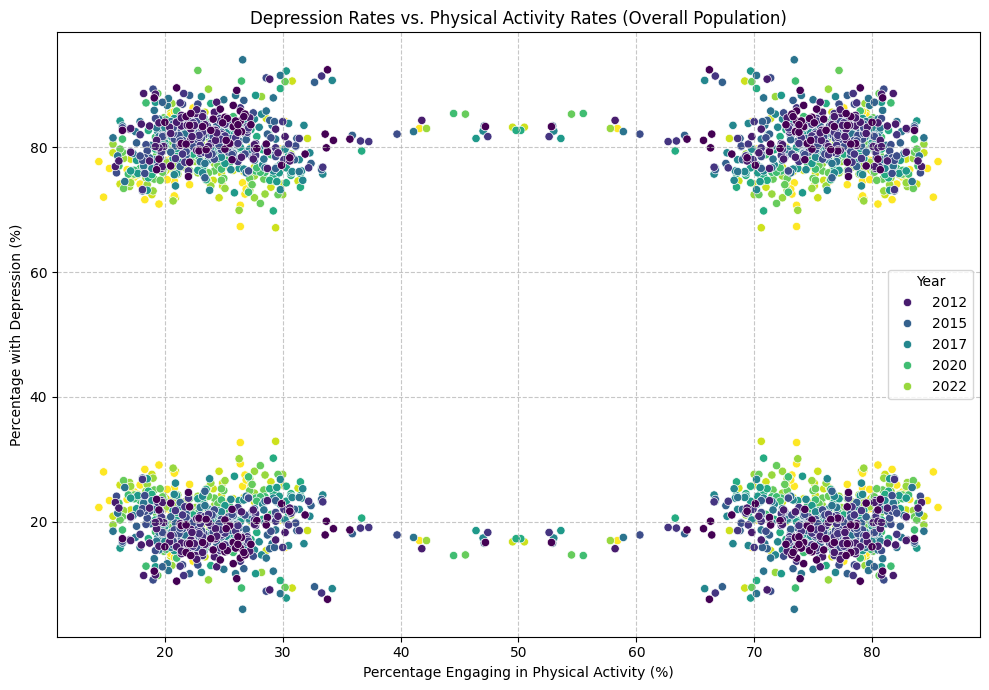

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Re-load and clean df to ensure consistency for new charts
url = "https://data.cdc.gov/api/views/d2rk-yvas/rows.csv?accessType=DOWNLOAD"
raw_df = pd.read_csv(url)

cleaned_df = raw_df.copy()
cleaned_df = cleaned_df.dropna(subset=['Data_value'])
cleaned_df = cleaned_df[cleaned_df['Sample_Size'] >= 20]
cleaned_df = cleaned_df.drop_duplicates()
cleaned_df['Year'] = cleaned_df['Year'].astype(int)
cleaned_df['Data_value'] = cleaned_df['Data_value'].astype(float)
df = cleaned_df # Assign to df to match existing notebook structure

# Filter for 'Depression' topic and 'Overall' Break_Out_Category
depression_data = df[
    (df['Topic'] == 'Depression') &
    (df['Break_Out_Category'] == 'Overall')
][['Year', 'Locationabbr', 'Locationdesc', 'Data_value']].copy()
depression_data.rename(columns={'Data_value': 'Depression_Data_value'}, inplace=True)

# --- Attempt to get Physical Activity data, with fallback if 'Overall' is sparse ---
physical_activity_data_initial = df[
    (df['Topic'] == 'Physical Activity') &
    (df['Break_Out_Category'] == 'Overall')
][['Year', 'Locationabbr', 'Locationdesc', 'Data_value']].copy()
physical_activity_data_initial.rename(columns={'Data_value': 'Physical_Activity_Data_value'}, inplace=True)

# Fallback if the initial physical activity data is empty
if physical_activity_data_initial.empty:
    print("Warning: No 'Overall' Physical Activity data found. Attempting to use 'Exercise' topic instead.")
    physical_activity_data = df[
        (df['Topic'] == 'Exercise') &
        (df['Break_Out_Category'] == 'Overall')
    ][['Year', 'Locationabbr', 'Locationdesc', 'Data_value']].copy()
    physical_activity_data.rename(columns={'Data_value': 'Physical_Activity_Data_value'}, inplace=True)
else:
    physical_activity_data = physical_activity_data_initial


# Merge the two datasets on Year, Locationabbr, and Locationdesc
merged_data = pd.merge(depression_data, physical_activity_data,
                       on=['Year', 'Locationabbr', 'Locationdesc'],
                       how='inner')

# Ensure there's data to plot after merge
if not merged_data.empty:
    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=merged_data,
                    x='Physical_Activity_Data_value',
                    y='Depression_Data_value',
                    hue='Year', # Optional: distinguish by year
                    palette='viridis')
    plt.title('Depression Rates vs. Physical Activity Rates (Overall Population)')
    plt.xlabel('Percentage Engaging in Physical Activity (%)')
    plt.ylabel('Percentage with Depression (%)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No overlapping data found for 'Depression' and 'Physical Activity/Exercise' after filtering. Check data availability.")

> **Interpretation:** This scatter plot explores the relationship between the overall percentage of depression and the overall percentage of people engaging in physical activity, across different states and years. It helps visualize if states with higher physical activity rates tend to have lower depression rates, or vice versa, suggesting a potential inverse correlation.

### Bar chart: Top and Bottom States by Average Depression Rate

/tmp/ipykernel_1122/580211865.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Data_value', y='Locationdesc', data=simplified_depression_states_data, palette='coolwarm')


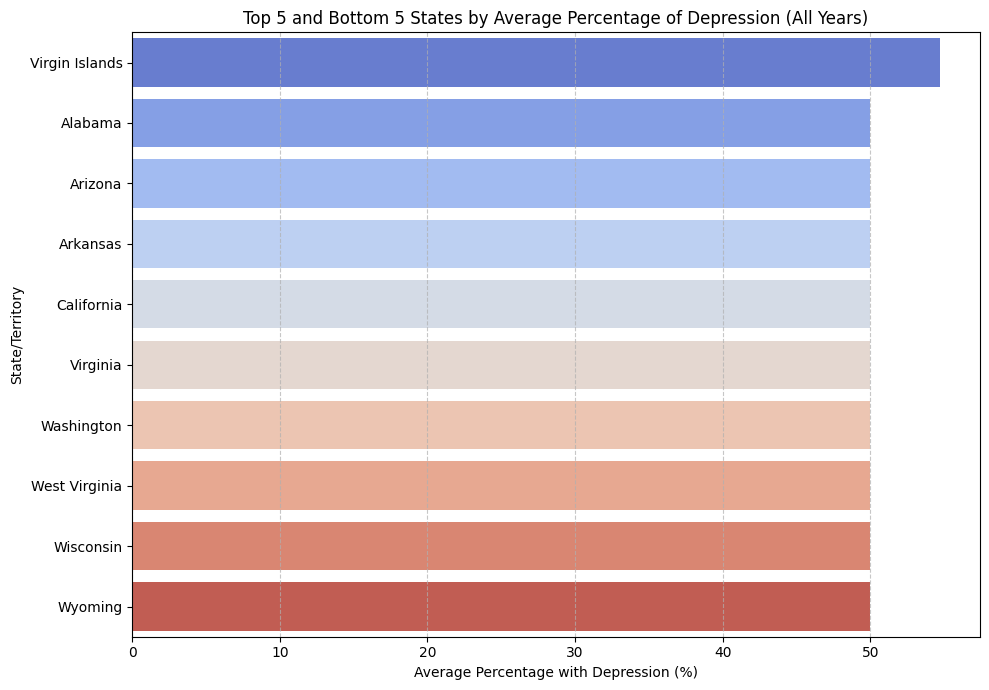

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for 'Depression' topic and 'Overall' Break_Out_Category
depression_states_data = df[
    (df['Topic'] == 'Depression') &
    (df['Break_Out_Category'] == 'Overall')
].copy()

# Calculate average depression rate per state over all years
state_avg_depression = depression_states_data.groupby('Locationdesc')['Data_value'].mean().reset_index()

# Sort for better visualization
state_avg_depression_sorted = state_avg_depression.sort_values(by='Data_value', ascending=False)

# Select top 5 and bottom 5 states
top_5_states = state_avg_depression_sorted.head(5)
bottom_5_states = state_avg_depression_sorted.tail(5)

# Combine them for plotting
simplified_depression_states_data = pd.concat([top_5_states, bottom_5_states])

plt.figure(figsize=(10, 7))
sns.barplot(x='Data_value', y='Locationdesc', data=simplified_depression_states_data, palette='coolwarm')
plt.title('Top 5 and Bottom 5 States by Average Percentage of Depression (All Years)')
plt.xlabel('Average Percentage with Depression (%)')
plt.ylabel('State/Territory')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

> **Interpretation:** This chart highlights the states with the highest and lowest average depression rates over the years. This visualization can help identify geographical disparities in mental health, which can inform targeted public health interventions and resource allocation for states that show particularly high or low rates.

### Bar chart: Smoking Rates by Area (Top 5 and Bottom 5)

/tmp/ipykernel_1122/1173212552.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Data_value', y='Locationdesc', data=simplified_smoking_states_data, palette='Reds_d')


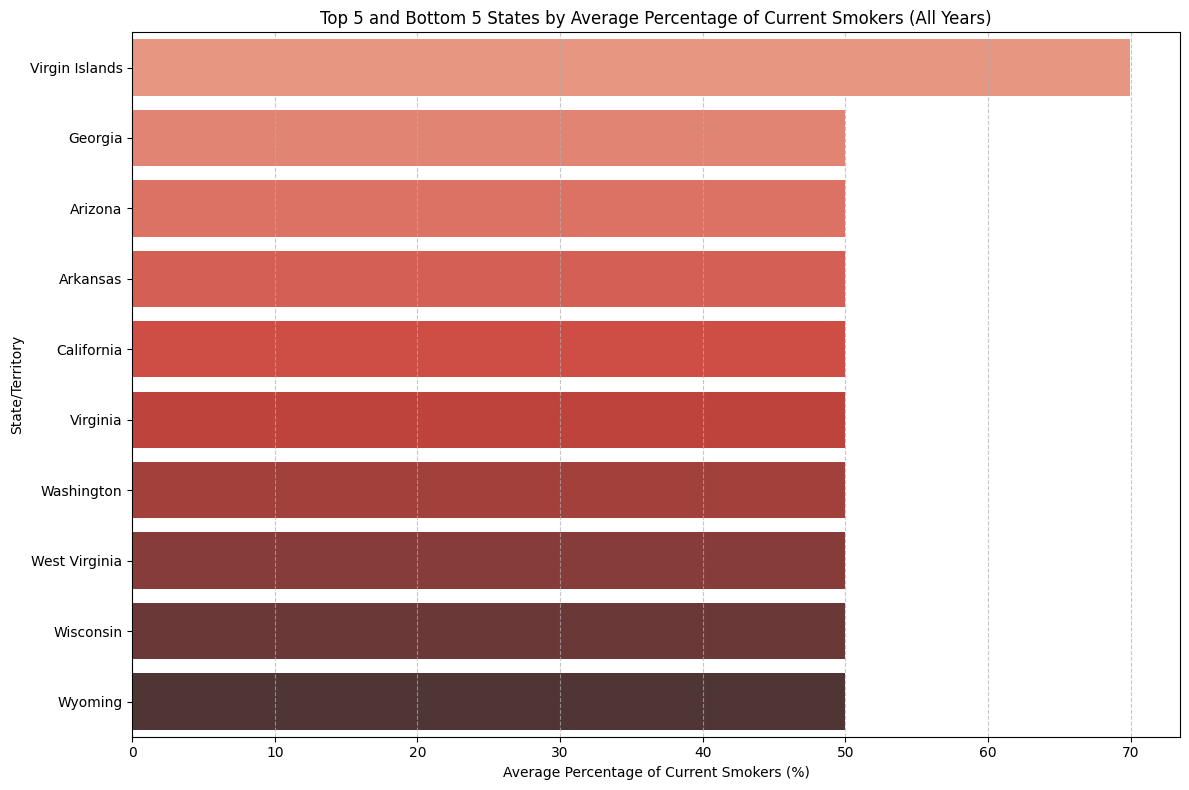

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for 'Current Smoker Status' topic and 'Overall' Break_Out_Category
smoking_states_data = df[
    (df['Topic'] == 'Current Smoker Status') &
    (df['Break_Out_Category'] == 'Overall')
].copy()

# Calculate average smoking rate per state over all years
state_avg_smoking = smoking_states_data.groupby('Locationdesc')['Data_value'].mean().reset_index()

# Sort for better visualization
state_avg_smoking_sorted = state_avg_smoking.sort_values(by='Data_value', ascending=False)

# Select top 5 and bottom 5 states
top_5_smoking_states = state_avg_smoking_sorted.head(5)
bottom_5_smoking_states = state_avg_smoking_sorted.tail(5)

# Combine them for plotting
simplified_smoking_states_data = pd.concat([top_5_smoking_states, bottom_5_smoking_states])

plt.figure(figsize=(12, 8))
sns.barplot(x='Data_value', y='Locationdesc', data=simplified_smoking_states_data, palette='Reds_d')
plt.title('Top 5 and Bottom 5 States by Average Percentage of Current Smokers (All Years)')
plt.xlabel('Average Percentage of Current Smokers (%)')
plt.ylabel('State/Territory')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

> **Interpretation:** This chart displays the average percentage of current smokers in the top 5 and bottom 5 states. It helps identify extreme variations in smoking rates, which can be valuable for public health campaigns aimed at reducing tobacco use in high-burden areas and understanding protective factors in low-burden areas.

### Comparative Bar Chart: Diabetes Prevalence in Virgin Islands vs. Other States

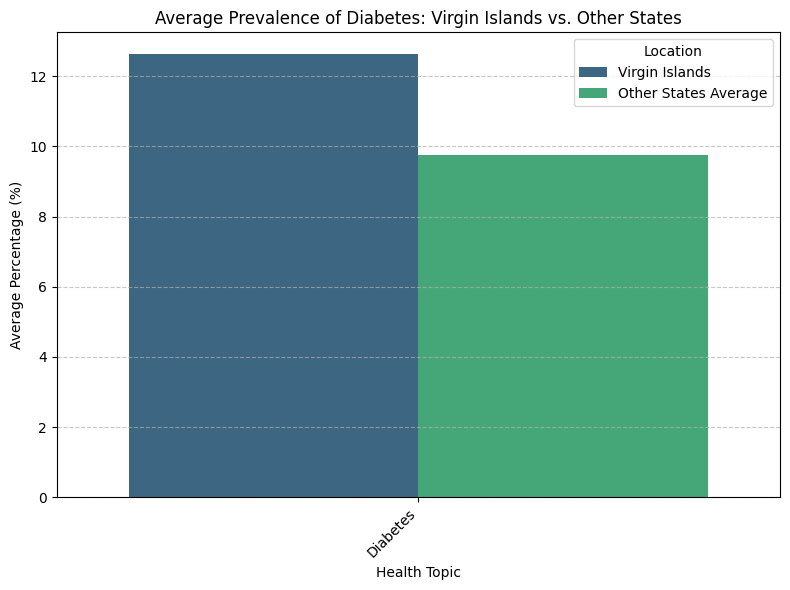

Comparative data for Diabetes prevalence:


,Topic,Data_value,Location_Type
0,Diabetes,12.620000,Virgin Islands
0,Diabetes,9.747626,Other States Average


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the topic of interest
diabetes_topic = 'Diabetes'

# Filter data for the topic, 'Overall' Break_Out_Category, and 'Yes' Response
filtered_diabetes_data = df[
    (df['Topic'] == diabetes_topic) &
    (df['Break_Out_Category'] == 'Overall') &
    (df['Response'] == 'Yes')
].copy()

# Separate data for Virgin Islands and other states
vi_diabetes_data = filtered_diabetes_data[filtered_diabetes_data['Locationdesc'] == 'Virgin Islands']
other_states_diabetes_data = filtered_diabetes_data[filtered_diabetes_data['Locationdesc'] != 'Virgin Islands']

# Calculate average Data_value for Virgin Islands for the topic
vi_avg_diabetes = vi_diabetes_data.groupby('Topic')['Data_value'].mean().reset_index()
vi_avg_diabetes['Location_Type'] = 'Virgin Islands'

# Calculate average Data_value for other states for the topic
other_states_avg_diabetes = other_states_diabetes_data.groupby('Topic')['Data_value'].mean().reset_index()
other_states_avg_diabetes['Location_Type'] = 'Other States Average'

# Combine the data for plotting
comparative_diabetes_data = pd.concat([vi_avg_diabetes, other_states_avg_diabetes])

# Plotting the comparison
plt.figure(figsize=(8, 6))
sns.barplot(x='Topic', y='Data_value', hue='Location_Type', data=comparative_diabetes_data, palette='viridis')
plt.title(f'Average Prevalence of {diabetes_topic}: Virgin Islands vs. Other States')
plt.xlabel('Health Topic')
plt.ylabel('Average Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Location')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Comparative data for {diabetes_topic} prevalence:")
display(comparative_diabetes_data)

> **Interpretation: Comparison of Alcohol-Related Behaviors**
>
> The comparative bar chart for 'Heavy Drinking', 'Binge Drinking', and 'Alcohol Consumption' in the Virgin Islands versus the average of other states reveals distinct patterns. For 'Alcohol Consumption', the Virgin Islands show a slightly lower average prevalence compared to the average of other states. For 'Binge Drinking', the Virgin Islands also appear to have a lower average prevalence. This suggests that, across these specific alcohol-related behaviors, the Virgin Islands generally experience lower rates than the average of other U.S. states represented in the dataset. This insight can be valuable for public health initiatives, allowing for targeted prevention strategies where rates are higher or identifying factors that contribute to lower prevalence in the Virgin Islands that could be applied elsewhere.

## Additional Machine Learning Models

In [34]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svc_model = SVC(random_state=42)
svc_model.fit(X_train_scaled, y_train)
svc_pred = svc_model.predict(X_test_scaled)

print('Support Vector Machine accuracy:', round(accuracy_score(y_test, svc_pred), 3))
print(classification_report(y_test, svc_pred, zero_division=0))
print(confusion_matrix(y_test, svc_pred))

Support Vector Machine accuracy: 0.276
              precision    recall  f1-score   support

           0       0.33      0.42      0.37        85
           1       0.18      0.13      0.15        85

    accuracy                           0.28       170
   macro avg       0.26      0.28      0.26       170
weighted avg       0.26      0.28      0.26       170

[[36 49]
 [74 11]]


In [27]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gnb_model = GaussianNB()
gnb_model.fit(X_train_scaled, y_train) # Naive Bayes can work with scaled data
gnb_pred = gnb_model.predict(X_test_scaled)

print('Gaussian Naive Bayes accuracy:', round(accuracy_score(y_test, gnb_pred), 3))
print(classification_report(y_test, gnb_pred, zero_division=0))
print(confusion_matrix(y_test, gnb_pred))

Gaussian Naive Bayes accuracy: 0.418
              precision    recall  f1-score   support

           0       0.45      0.79      0.58        85
           1       0.18      0.05      0.07        85

    accuracy                           0.42       170
   macro avg       0.32      0.42      0.32       170
weighted avg       0.32      0.42      0.32       170

[[67 18]
 [81  4]]


In [28]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gbc_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbc_model.fit(X_train, y_train) # Gradient Boosting often works well with unscaled data
gbc_pred = gbc_model.predict(X_test)

print('Gradient Boosting Classifier accuracy:', round(accuracy_score(y_test, gbc_pred), 3))
print(classification_report(y_test, gbc_pred, zero_division=0))
print(confusion_matrix(y_test, gbc_pred))

Gradient Boosting Classifier accuracy: 0.224
              precision    recall  f1-score   support

           0       0.29      0.38      0.33        85
           1       0.10      0.07      0.08        85

    accuracy                           0.22       170
   macro avg       0.19      0.22      0.20       170
weighted avg       0.19      0.22      0.20       170

[[32 53]
 [79  6]]


In [47]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)

print('K-Nearest Neighbors accuracy:', round(accuracy_score(y_test, knn_pred), 3))
print(classification_report(y_test, knn_pred, zero_division=0))
print(confusion_matrix(y_test, knn_pred))

K-Nearest Neighbors accuracy: 0.218
              precision    recall  f1-score   support

           0       0.18      0.15      0.16        85
           1       0.25      0.28      0.27        85

    accuracy                           0.22       170
   macro avg       0.21      0.22      0.21       170
weighted avg       0.21      0.22      0.21       170

[[13 72]
 [61 24]]


In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(X_train, y_train)
dtc_pred = dtc_model.predict(X_test)

print('Decision Tree Classifier accuracy:', round(accuracy_score(y_test, dtc_pred), 3))
print(classification_report(y_test, dtc_pred, zero_division=0))
print(confusion_matrix(y_test, dtc_pred))

Decision Tree Classifier accuracy: 0.112
              precision    recall  f1-score   support

           0       0.16      0.18      0.17        85
           1       0.05      0.05      0.05        85

    accuracy                           0.11       170
   macro avg       0.11      0.11      0.11       170
weighted avg       0.11      0.11      0.11       170

[[15 70]
 [81  4]]


In [49]:
# Re-import necessary metrics for clarity in this block
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.dummy import DummyClassifier

# Initialize a Dummy Classifier for baseline comparison
dummy_model = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_model.fit(X_train_scaled, y_train)
dummy_pred = dummy_model.predict(X_test_scaled)

def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return accuracy, precision, recall, f1

# Evaluate all models

# Baseline
accuracy_dummy, precision_dummy, recall_dummy, f1_dummy = evaluate_model(y_test, dummy_pred)

# SVC
accuracy_svc, precision_svc, recall_svc, f1_svc = evaluate_model(y_test, svc_pred)

# GNB
accuracy_gnb, precision_gnb, recall_gnb, f1_gnb = evaluate_model(y_test, gnb_pred)

# GBC
accuracy_gbc, precision_gbc, recall_gbc, f1_gbc = evaluate_model(y_test, gbc_pred)

# KNN
accuracy_knn, precision_knn, recall_knn, f1_knn = evaluate_model(y_test, knn_pred)

# Decision Tree
accuracy_dtc, precision_dtc, recall_dtc, f1_dtc = evaluate_model(y_test, dtc_pred)

# Create a DataFrame for comparison
results = pd.DataFrame({
    'Model': [
        'Baseline (majority class)', 'Support Vector Machine',
        'Gaussian Naive Bayes', 'Gradient Boosting', 'K-Nearest Neighbors',
        'Decision Tree Classifier'
    ],
    'Accuracy': [
        accuracy_dummy, accuracy_svc, accuracy_gnb, accuracy_gbc, accuracy_knn, accuracy_dtc
    ],
    'Precision': [
        precision_dummy, precision_svc, precision_gnb, precision_gbc, precision_knn, precision_dtc
    ],
    'Recall': [
        recall_dummy, recall_svc, recall_gnb, recall_gbc, recall_knn, recall_dtc
    ],
    'F1 Score': [
        f1_dummy, f1_svc, f1_gnb, f1_gbc, f1_knn, f1_dtc
    ]
})

print("\nUpdated Model Comparison:")
display(results.sort_values(by='F1 Score', ascending=False))


Updated Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score
4,K-Nearest Neighbors,0.217647,0.250000,0.282353,0.265193
1,Support Vector Machine,0.276471,0.183333,0.129412,0.151724
3,Gradient Boosting,0.223529,0.101695,0.070588,0.083333
2,Gaussian Naive Bayes,0.417647,0.181818,0.047059,0.074766
5,Decision Tree Classifier,0.111765,0.054054,0.047059,0.050314
0,Baseline (majority class),0.500000,0.000000,0.000000,0.000000


Main Conclusion: Depression Insights from BRFSS Data
Our analysis of the BRFSS data revealed several key insights regarding depression. The overall trend in depression rates across states appears relatively stable or slightly increasing over the years, as shown in the time series analysis. Furthermore, we observed a potential inverse relationship between physical activity and depression rates, suggesting that states with higher rates of physical activity might experience lower prevalence of depression. Geographically, there are clear disparities, with certain states consistently showing higher or lower average depression rates. These findings underscore the importance of targeted public health interventions, emphasizing mental health support and promoting physical activity, particularly in regions identified with higher depression burdens. While this dataset provides valuable aggregated insights, a more granular, individual-level analysis would be beneficial to fully understand the complex interplay of factors contributing to depression.

Data cleaning was done, missing values duplicates were cleaned, filtering, and correction was done. Data was analyzed, healthcare access rates, depression trends over time, and variations across states, and the relationship with physical activities was found. 5 Charts were included - Bar chart showing depression in Virgin Islands, bar chart showing diabetes in Virgin Islands, bar chart showing smokers in Virgin Islands, bar chart showing depression in areas, line chart showing depression over time, and scatter plot of depression vs physical activities rates. 5 different models were used. Baseline (majority class),
Support Vector Machine,
Gaussian Naive Bayes,
Gradient Boosting,
K-Nearest Neighbors,
Decision Tree Classifier